In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv("D:/Intro-Brief_Challenge-23_English/Airline Delays_English_C23.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3351 entries, 0 to 3350
Data columns (total 23 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Year                                               3351 non-null   int64  
 1   Month                                              3351 non-null   int64  
 2   Carrier ID                                         3351 non-null   object 
 3   Carrier Name                                       3351 non-null   object 
 4   Airport (3 letter Code)                            3351 non-null   object 
 5   Airport Name                                       3351 non-null   object 
 6   Latitude                                           3351 non-null   float64
 7   Longitude                                          3351 non-null   float64
 8   Total Flights Arrival                              3351 non-null   int64  
 9   Total Ar

In [4]:
df.describe()

,Year,Month,Latitude,Longitude,Total Flights Arrival,Total Arrivals >15 Delay (Minutes),Total Delays Due to Carrier's Reasons,Total Delays Due to Weather,Total Delays Due to National Aviation Systems,Total Delays Due to security Breach,Total Delays Due to Late Aircraft,Total Cancelled Flights,Total Diverted Flights,Delay Due to Late Arrival (Minutes),Delays Due to Carriers' Resons (Minutes),Delays Due to Weather (Minutes),Dealys Due to National Aviation Systems (Minutes),Dealys Due to Security Breach (Minutes),Delays Due to Late Aircraft (Minutes)
count,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000,3351.000000
mean,2023.459266,6.445837,30.159189,-79.992836,297.558938,50.873471,16.027454,1.435392,16.137869,0.135482,17.133393,2.877648,0.574455,3325.911370,1142.030140,177.167413,747.789913,5.387944,1253.533572
std,0.498412,3.463840,21.557708,52.392343,851.542351,146.330616,41.714085,4.823443,56.364396,0.651174,55.389054,10.115539,2.095566,10273.927208,3367.539489,733.517408,3186.907338,27.130231,4179.902049
min,2023.000000,1.000000,-54.822700,-170.710007,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2023.000000,3.000000,30.407301,-98.273783,34.000000,5.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,228.500000,66.000000,0.000000,21.000000,0.000000,30.000000
50%,2023.000000,6.000000,36.475201,-86.753502,82.000000,12.000000,5.000000,0.000000,3.000000,0.000000,3.000000,0.000000,0.000000,742.000000,270.000000,3.000000,106.000000,0.000000,204.000000
75%,2024.000000,9.000000,41.303200,-77.455803,194.000000,33.000000,12.000000,1.000000,9.000000,0.000000,10.000000,2.000000,0.000000,2083.500000,826.500000,82.000000,361.500000,0.000000,722.500000
max,2024.000000,12.000000,76.018613,153.288242,19713.000000,2289.000000,697.000000,89.000000,1040.000000,17.000000,820.000000,224.000000,42.000000,160383.000000,55215.000000,14219.000000,82064.000000,553.000000,75179.000000


In [5]:
df.columns

Index(['Year', 'Month', 'Carrier ID', 'Carrier Name',
       'Airport (3 letter Code)', 'Airport Name', 'Latitude', 'Longitude',
       'Total Flights Arrival', 'Total Arrivals  >15 Delay (Minutes)',
       'Total Delays Due to Carrier's Reasons', 'Total Delays Due to Weather',
       'Total Delays Due to National Aviation Systems',
       'Total Delays Due to security Breach',
       'Total Delays Due to Late Aircraft', 'Total Cancelled Flights',
       'Total Diverted Flights', 'Delay Due to Late Arrival (Minutes)',
       'Delays Due to Carriers' Resons (Minutes)',
       'Delays Due to Weather (Minutes)',
       'Dealys Due to National Aviation Systems (Minutes)',
       'Dealys Due to Security Breach (Minutes)',
       'Delays Due to Late Aircraft (Minutes)'],
      dtype='object')

In [6]:
#total flights
Total_Flights=df['Total Flights Arrival'].sum()
print(f"Total_Flights:{Total_Flights:,}")

Total_Flights:997,120


In [7]:
#total delayed flights
Delayed_flights=df['Total Arrivals  >15 Delay (Minutes)'].sum()
print(f"Delayed_flights:{Delayed_flights:,}")

Delayed_flights:170,477


In [8]:
#delayed Rate
df['Delay Rate(%)']=(df['Total Arrivals  >15 Delay (Minutes)']/df['Total Flights Arrival'])*100


In [9]:
delay_rate = (df["Total Arrivals  >15 Delay (Minutes)"].sum() /
              df["Total Flights Arrival"].sum()) * 100

print(f"Overall Delay Rate: {delay_rate:.2f}%")

Overall Delay Rate: 17.10%


In [10]:
df[["Total Flights Arrival",
          "Total Arrivals  >15 Delay (Minutes)",
          "Delay Rate(%)"]].head(10)

,Total Flights Arrival,Total Arrivals >15 Delay (Minutes),Delay Rate(%)
0,44,3,6.818182
1,90,1,1.111111
2,88,8,9.090909
3,184,9,4.891304
4,76,11,14.473684
5,5985,445,7.435255
6,142,14,9.859155
7,147,10,6.802721
8,84,14,16.666667
9,150,19,12.666667


In [11]:
top_10 = df.sort_values(
    by="Delay Rate(%)", ascending=False
).head(10)
print(top_10[["Airport Name","Delay Rate(%)"]])

                                     Airport Name  Delay Rate(%)
2171                  Miami International Airport     100.000000
1440                      Mobile Regional Airport     100.000000
100       Southwest Florida International Airport     100.000000
1620        Roanokeâ€“Blacksburg Regional Airport     100.000000
1515         Piedmont Triad International Airport     100.000000
451              Burlington International Airport     100.000000
1425  Huntsville International Carl T Jones Field     100.000000
2600                              Mirsey Airstrip     100.000000
207                             Andakombe Airport      88.888889
3345                 Albany International Airport      75.000000


In [12]:
delay_columns = [
       'Delay Due to Late Arrival (Minutes)',
       "Delays Due to Carriers' Resons (Minutes)",
       'Delays Due to Weather (Minutes)',
       'Dealys Due to National Aviation Systems (Minutes)',
       'Dealys Due to Security Breach (Minutes)',
       'Delays Due to Late Aircraft (Minutes)'
]
df['Total Delay Minutes']=df[delay_columns].sum(axis=1)

In [13]:
print(df[['Total Delay Minutes']].head(10))

   Total Delay Minutes
0                  178
1                   46
2                  676
3                 1016
4                 1384
5                61512
6                  872
7                 2140
8                 4012
9                 1692


In [14]:
print("Total Delay Minutes:", df['Total Delay Minutes'].sum())

Total Delay Minutes: 22290250


In [15]:
total_delay_hours = df['Total Delay Minutes'].sum() / 60

print(f"Total Delay Hours: {total_delay_hours:.2f} hours")

Total Delay Hours: 371504.17 hours


In [16]:
Total_cancelled=df['Total Cancelled Flights'].sum()
print(f" Total Flights:{Total_cancelled:,}")

 Total Flights:9,643


In [17]:
Cancelled_Rate = (df['Total Cancelled Flights'].sum()/
                 df['Total Flights Arrival'].sum()) * 100

print(f"Overall Cancelled_Rate: {Cancelled_Rate:.2f}%")

Overall Cancelled_Rate: 0.97%


In [18]:
Total_Diverted_Flights=df['Total Diverted Flights'].sum()
print(f"Diverted_flithts: {Total_Diverted_Flights:,}")

Diverted_flithts: 1,925


In [24]:
Diverted_Rate=(df['Total Diverted Flights'].sum()/df['Total Flights Arrival'].sum())*100
print(f'Diverted_Rate:{Diverted_Rate:.2f}%')

Diverted_Rate:0.19%


In [20]:
delay_rate = (df["Total Arrivals  >15 Delay (Minutes)"].sum() /
              df["Total Flights Arrival"].sum()) * 100

print(f"Overall Delay Rate: {delay_rate:.2f}%")

Overall Delay Rate: 17.10%


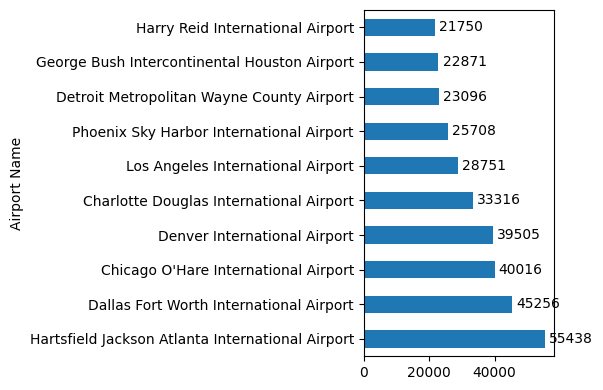

In [38]:
#bussiest airport  bby flights
top_10_airports_by_flights=df.groupby('Airport Name')['Total Flights Arrival'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))

ax = top_10_airports_by_flights.plot(kind='barh')

ax.bar_label(ax.containers[0], fmt = '%d', padding=3)

plt.tight_layout()
plt.show()

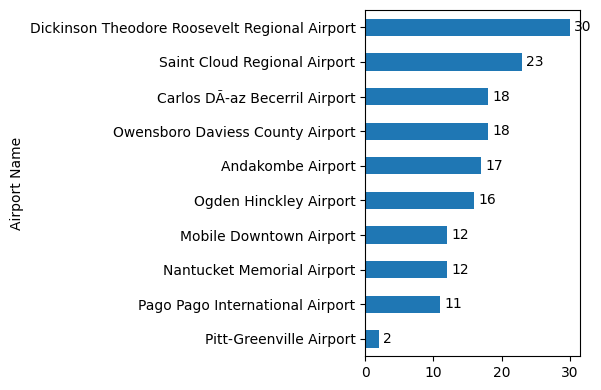

In [39]:
#least bussiest airport by flights 
# logic group > sum flight > sort highest >top 10 > reverse order  for horizontal chart
bottom_10_airports_by_flights=df.groupby('Airport Name')['Total Flights Arrival'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(6,4))

ax = bottom_10_airports_by_flights.plot(kind='barh')

ax.bar_label(ax.containers[0], fmt = '%d', padding=3)

plt.tight_layout()
plt.show()

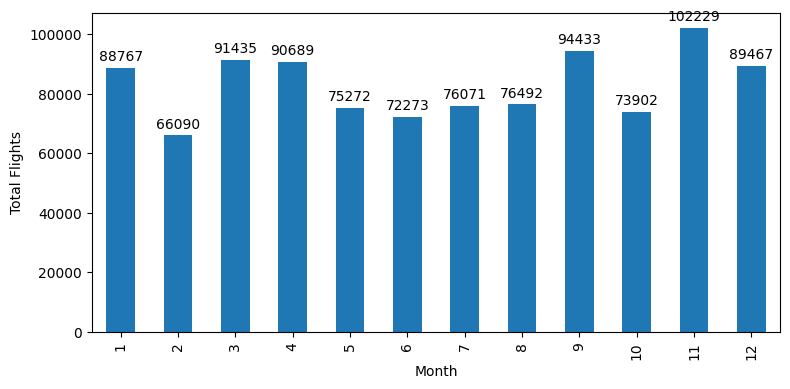

In [45]:
#bussiest month by flithts so
#group > sum flight > sort >top 10 > bar chart vertical

Bussiest_months = df.groupby('Month')['Total Flights Arrival'].sum().sort_index()

plt.figure(figsize=(8,4))

ax=Bussiest_months.plot(kind='bar')

ax.bar_label(ax.containers[0],fmt='%d', padding = 3)

plt.ylabel('Total Flights')
plt.tight_layout()
plt.show()

In [59]:
#BUSSIEST AIRPORT MONTH
df.groupby(['Airport Name','Month'])['Total Flights Arrival'].sum().reset_index().sort_values('Total Flights Arrival',ascending=False).head(10)

,Airport Name,Month,Total Flights Arrival
722,Hartsfield Jackson Atlanta International Airport,9,26131
388,Dallas Fort Worth International Airport,4,19391
725,Hartsfield Jackson Atlanta International Airport,12,16664
1515,Salt Lake City International Airport,11,12469
427,Denver International Airport,10,10844
385,Dallas Fort Worth International Airport,1,10364
307,Charlotte Douglas International Airport,5,9910
395,Dallas Fort Worth International Airport,12,9759
1627,Seattleâ€“Tacoma International Airport,7,9669
312,Charlotte Douglas International Airport,11,9225


In [75]:
#delay rate by month
delay_flights = df.groupby('Month')['Total Arrivals  >15 Delay (Minutes)'].sum().sort_index()
print(delay_rate)

Month
1     17037
2     11485
3     16253
4     16376
5     13607
6     11645
7     13553
8     11957
9     14564
10    12314
11    17920
12    13766
Name: Total Arrivals  >15 Delay (Minutes), dtype: int64


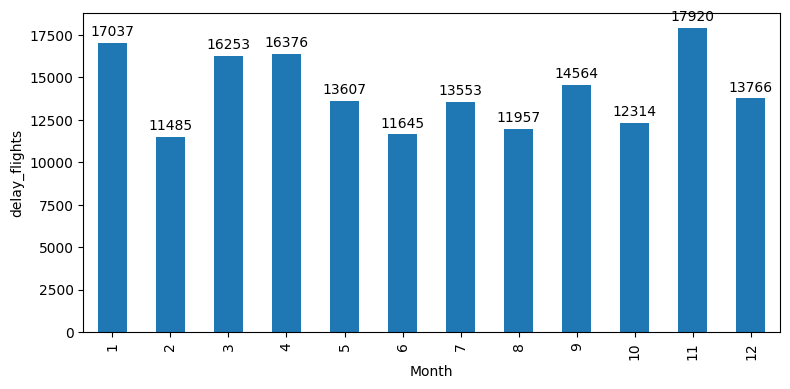

In [84]:
delay_flights = df.groupby('Month')['Total Arrivals  >15 Delay (Minutes)'].sum().sort_index()

plt.figure(figsize=(8,4))

ax=delay_flights.plot(kind='bar')

ax.bar_label(ax.containers[0],fmt='%d',padding = 3)
plt.ylabel('delay_flights')
plt.tight_layout()
plt.show()

In [83]:
#delay rate by month
delay_rate = df.groupby('Month').agg(
    Delayed_Flights=('Total Arrivals  >15 Delay (Minutes)', 'sum'),
    Total_Flights=('Total Flights Arrival', 'sum')
)

delay_rate['Delay Rate (%)'] = (
    delay_rate['Delayed_Flights'] /
    delay_rate['Total_Flights']
) * 100

print(delay_rate)

       Delayed_Flights  Total_Flights  Delay Rate (%)
Month                                                
1                17037          88767       19.192943
2                11485          66090       17.377818
3                16253          91435       17.775469
4                16376          90689       18.057317
5                13607          75272       18.077107
6                11645          72273       16.112518
7                13553          76071       17.816251
8                11957          76492       15.631700
9                14564          94433       15.422575
10               12314          73902       16.662607
11               17920         102229       17.529273
12               13766          89467       15.386679


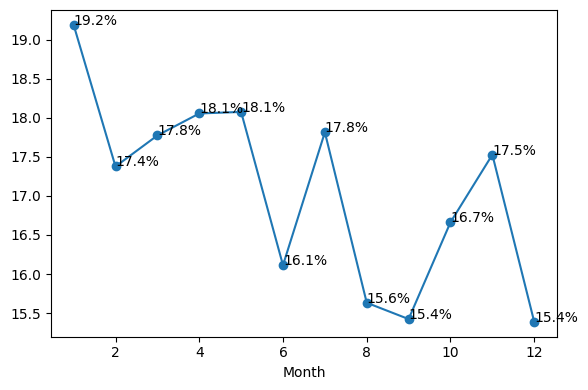

In [95]:
delay_rate = delay_rate.sort_index()
plt.figure(figsize=(6,4))
ax = delay_rate['Delay Rate (%)'].plot(kind='line',marker='o')

for x, y in zip(delay_rate.index, delay_rate['Delay Rate (%)']):
    ax.text(x, y, f'{y:.1f}%')
    
plt.tight_layout()
plt.show()


In [100]:
#airline with most delayed patterns
airline_delay = df.groupby('Carrier Name')['Total Arrivals  >15 Delay (Minutes)'].sum().sort_values(ascending=False)
print(airline_delay)

Carrier Name
Southwest Airlines Co.     30578
SkyWest Airlines Inc.      20674
American Airlines Inc.     18944
Delta Air Lines Inc.       18863
United Air Lines Inc.      13498
JetBlue Airways            10363
Envoy Air                   8070
Republic Airline            7932
PSA Airlines Inc.           7162
Mesa Airlines Inc.          6359
Alaska Airlines Inc.        6294
Endeavor Air Inc.           5860
Spirit Air Lines            5020
Frontier Airlines Inc.      3654
Allegiant Air               3480
ExpressJet Airlines LLC     2694
Hawaiian Airlines Inc.      1032
Name: Total Arrivals  >15 Delay (Minutes), dtype: int64


In [104]:
airline_delay=df.groupby('Carrier Name').agg(
    delayed=('Total Arrivals  >15 Delay (Minutes)','sum'),
    total=('Total Flights Arrival','sum')
)

airline_delay['Delay Rate%'] =(airline_delay['delayed']/airline_delay['total'])*100

airline_delay = airline_delay.sort_values('Delay Rate%',ascending=False)

print(airline_delay)

                         delayed   total  Delay Rate%
Carrier Name                                         
JetBlue Airways            10363   36181    28.642105
ExpressJet Airlines LLC     2694   11203    24.047130
Mesa Airlines Inc.          6359   30502    20.847813
Allegiant Air               3480   16749    20.777360
Alaska Airlines Inc.        6294   33001    19.072149
Frontier Airlines Inc.      3654   19587    18.655231
PSA Airlines Inc.           7162   38567    18.570280
Envoy Air                   8070   43914    18.376827
United Air Lines Inc.      13498   77183    17.488307
Southwest Airlines Co.     30578  178784    17.103320
Spirit Air Lines            5020   30044    16.708827
SkyWest Airlines Inc.      20674  126678    16.320119
American Airlines Inc.     18944  117901    16.067718
Republic Airline            7932   50134    15.821598
Delta Air Lines Inc.       18863  130902    14.410017
Endeavor Air Inc.           5860   45375    12.914601
Hawaiian Airlines Inc.      

<Figure size 800x400 with 0 Axes>

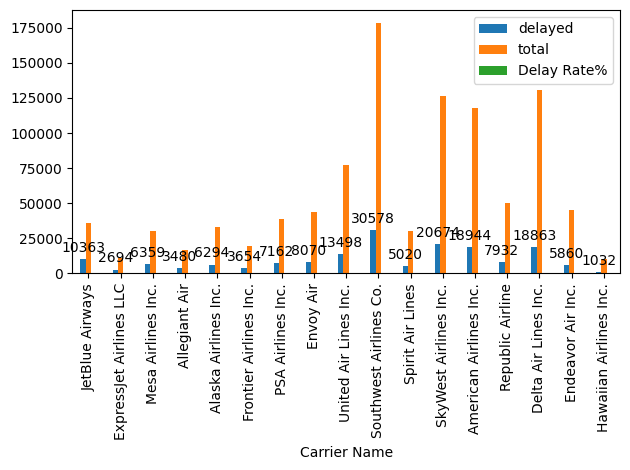

In [113]:
plt.figure(figsize=(8,4))

ax=airline_delay.plot(kind='bar')
ax.bar_label(ax.containers[0],fmt='%d',padding = 3)

plt.tight_layout()
plt.show()


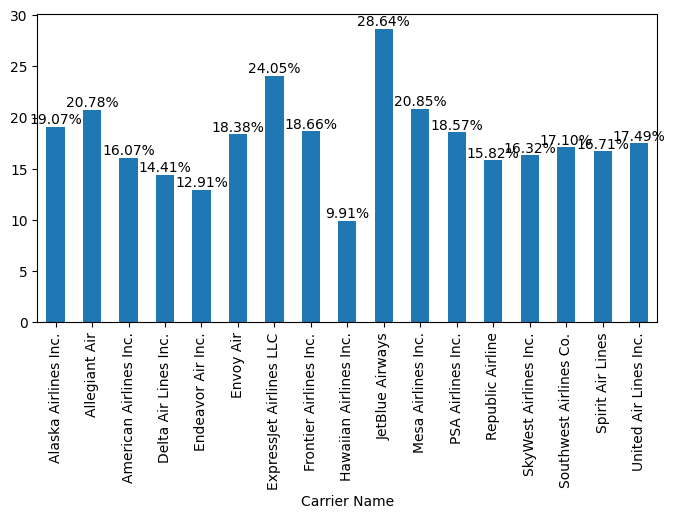

In [124]:
#percentage of delayed flights by aitlines
plotting= df.groupby('Carrier Name')[['Total Arrivals  >15 Delay (Minutes)','Total Flights Arrival']].apply(
    lambda x:(x["Total Arrivals  >15 Delay (Minutes)"].sum() /
              x["Total Flights Arrival"].sum()) * 100
)
plt.figure(figsize=(8,4))

ax=plotting.plot(kind='bar')
ax.bar_label(ax.containers[0],fmt='%.2f%%')

ax = delay_rate

In [125]:
#primary reasons fo the delay
delay_causes=df[
    ["Total Delays Due to Carrier's Reasons", 'Total Delays Due to Weather',
       'Total Delays Due to National Aviation Systems',
       'Total Delays Due to security Breach',
       'Total Delays Due to Late Aircraft',]
    ].sum().sort_values(ascending=False)

print(delay_causes)

Total Delays Due to Late Aircraft                57414
Total Delays Due to National Aviation Systems    54078
Total Delays Due to Carrier's Reasons            53708
Total Delays Due to Weather                       4810
Total Delays Due to security Breach                454
dtype: int64


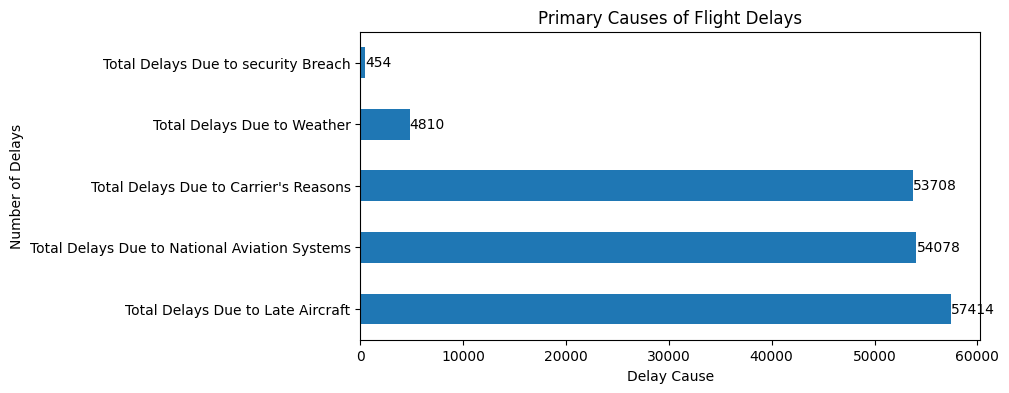

In [127]:
plt.figure(figsize=(8,4))

ax = delay_causes.plot(kind='barh')

ax.set_xlabel('Delay Cause')
ax.set_ylabel('Number of Delays')
ax.set_title('Primary Causes of Flight Delays')

ax.bar_label(ax.containers[0], fmt='%.0f')

plt.show()

In [143]:
#airport effected by wether related delay
airport_weather_delay=df.groupby('Airport Name')['Total Delays Due to Weather'].sum().sort_values(ascending=False).head(10)
print(airport_weather_delay)

Airport Name
Dallas Fort Worth International Airport             297
Chicago O'Hare International Airport                248
Marcos Paz Airfield                                 210
Hartsfield Jackson Atlanta International Airport    178
Denver International Airport                        175
Detroit Metropolitan Wayne County Airport           163
Salt Lake City International Airport                154
Los Angeles International Airport                   125
George Bush Intercontinental Houston Airport        110
Charlotte Douglas International Airport             105
Name: Total Delays Due to Weather, dtype: int64


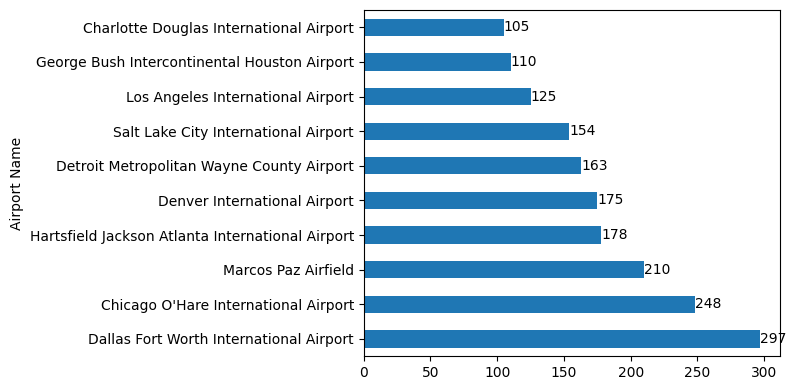

In [144]:
plt.figure(figsize=(8,4))

ax = airport_weather_delay.plot(kind='barh')

ax.bar_label(ax.containers[0])

plt.tight_layout()
plt.show()

In [161]:
df['Season']=df['Month'].apply(lambda x: 'Peak' if x in[1,6,7,8,11,12] else 'Off-Peak')

In [162]:
season_delay = df.groupby('Season')[
    ['Total Arrivals  >15 Delay (Minutes)', 'Total Flights Arrival']
    ].apply(
    lambda x: (x['Total Arrivals  >15 Delay (Minutes)'].sum() /
               x['Total Flights Arrival'].sum()) * 100
)

print(season_delay)

Season
Off-Peak    17.201177
Peak        16.995482
dtype: float64


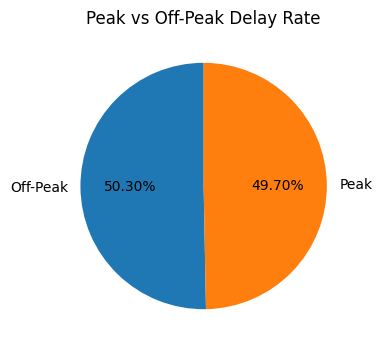

In [163]:
plt.figure(figsize=(4,4))

season_delay.plot(
    kind='pie',
    autopct='%.2f%%',
    startangle=90
)

plt.ylabel('')
plt.title('Peak vs Off-Peak Delay Rate')

plt.show()

In [130]:
df.columns

Index(['Year', 'Month', 'Carrier ID', 'Carrier Name',
       'Airport (3 letter Code)', 'Airport Name', 'Latitude', 'Longitude',
       'Total Flights Arrival', 'Total Arrivals  >15 Delay (Minutes)',
       'Total Delays Due to Carrier's Reasons', 'Total Delays Due to Weather',
       'Total Delays Due to National Aviation Systems',
       'Total Delays Due to security Breach',
       'Total Delays Due to Late Aircraft', 'Total Cancelled Flights',
       'Total Diverted Flights', 'Delay Due to Late Arrival (Minutes)',
       'Delays Due to Carriers' Resons (Minutes)',
       'Delays Due to Weather (Minutes)',
       'Dealys Due to National Aviation Systems (Minutes)',
       'Dealys Due to Security Breach (Minutes)',
       'Delays Due to Late Aircraft (Minutes)', 'Delay Rate(%)',
       'Total Delay Minutes'],
      dtype='object')

In [168]:
#top 5 airport delay by latitude and longitude
top_5 = airport_delay.sort_values('Delay Rate (%)', ascending=False).head(5)
print(top_5[['Delay Rate (%)', 'latitude', 'longitude']])

                                  Delay Rate (%)   latitude   longitude
Airport Name                                                           
Andakombe Airport                      52.941176  -7.137222  145.744722
Carlos DÃ­az Becerril Airport          50.000000  19.237100 -101.679520
Mercedita Airport                      37.931034  18.008301  -66.563004
Concord-Padgett Regional Airport       33.333333  35.387770  -80.709130
Nantucket Memorial Airport             33.333333  41.253101  -70.060204


In [169]:
delay_percentage = (
    df['Total Arrivals  >15 Delay (Minutes)'].sum()
    / df['Total Flights Arrival'].sum()
) * 100

print(f"Percentage of flights delayed over 15 minutes: {delay_percentage:.2f}%")

Percentage of flights delayed over 15 minutes: 17.10%


In [172]:
#10.Are there airports or airlines with significantly better on-time performance?
airline_performance = df.groupby('Carrier Name')['Delay Rate(%)'].mean().sort_values(ascending=False).head(5)
airport_performance = df.groupby('Airport Name')['Delay Rate(%)'].mean().sort_values(ascending=False).head(5)

print(airport_performance)
print(airline_performance)

Airport Name
Andakombe Airport                          50.694444
Carlos DÃ­az Becerril Airport              50.000000
Mercedita Airport                          37.931034
Rafael HernÃ¡ndez International Airport    37.787764
Nantucket Memorial Airport                 33.333333
Name: Delay Rate(%), dtype: float64
Carrier Name
JetBlue Airways            25.393469
ExpressJet Airlines LLC    23.702901
Mesa Airlines Inc.         21.166910
Hawaiian Airlines Inc.     17.690051
PSA Airlines Inc.          17.324604
Name: Delay Rate(%), dtype: float64
